# **Fichier d'analyse des résulats**

## Chargement librairies etc

In [176]:
import pandas as pd
import json

import matplotlib.pyplot as plt
from matplotlib import font_manager
import os


In [177]:
# Paramètres pour les graphiques
font_dir = "assets"

for file in os.listdir(font_dir):
    if file.endswith(".ttf"):
        font_manager.fontManager.addfont(os.path.join(font_dir, file))

plt.rcParams["font.family"] = "Marianne"
plt.rcParams.update({
    "font.family": "Marianne",

    "axes.titlesize": 16,
    "axes.titleweight": "bold",

    "figure.titlesize": 18,
    "figure.titleweight": "bold",

    "axes.labelsize": 12,
    "axes.labelweight": "regular",

    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "legend.fontsize": 10,
})

# Colors and styles for plotting
palette = {
    "Solar":      "#d66b0d",
    "Hydro":        "#2672b0",
    "Onshore":      "#72cbb7",
    "Offshore":     "#4d8377",
    "H2_CCG":       "#e4a701",
    "H2_TAC":       "#f0c040",
    "STEP_charge":  "#7a1616",
    "Fond":         "#ffffff",
    "STEP_discharge": "#ff0000",
    "Battery_charge": "#4B1063",
    "Battery_discharge": "#d126c9",
    "Battery" : "#8226A7",
}

# Colonnes production (positives)
prod_cols = [
    'H2_CCG','H2_TAC','Hydro','Onshore','Offshore',
    'STEP_discharge','Battery_discharge','Solar'
]

# Colonnes charge
charge_cols = [
    'STEP_charge','Battery_charge'
]

In [178]:
df_global = pd.read_csv('results/annual/results.csv', sep=';')
df_global.drop(columns=['t'], inplace=True)

parc = json.load(open('results/annual/parc_annuel.json', 'r'))

evolution_parc = json.load(open("results/annual/evolution_parc.json", "r"))

In [179]:
WEEK_TO_PLOT = 0
df = df_global.iloc[WEEK_TO_PLOT*7*24:(WEEK_TO_PLOT+1)*7*24]

## **1. EOD : vue générale**

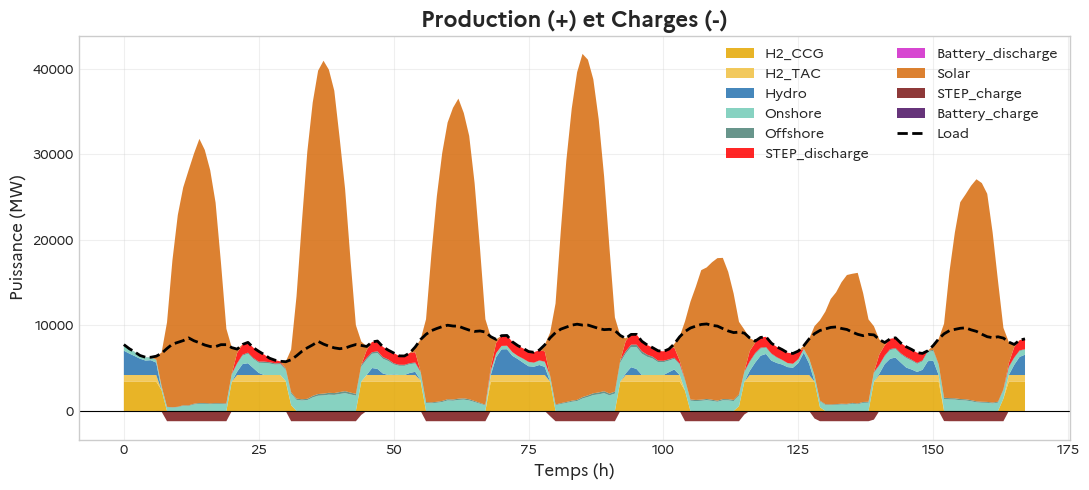

In [180]:
plt.figure(figsize=(11,5))

# --- STACK POSITIF ---
plt.stackplot(
    df.index,
    [df[c] for c in prod_cols],
    colors=[palette[c] for c in prod_cols],
    labels=prod_cols,
    alpha=0.85
)

# --- STACK NEGATIF ---
plt.stackplot(
    df.index,
    [-df[c] for c in charge_cols],   # ⚠️ on met en négatif
    colors=[palette[c] for c in charge_cols],
    labels=charge_cols,
    alpha=0.85
)

# Ligne zéro
plt.axhline(0, color="black", linewidth=0.8)

# Load
plt.plot(df.index, df['Load'], color="black", linestyle='--', linewidth=2, label="Load")

plt.title("Production (+) et Charges (-)")
plt.xlabel("Temps (h)")
plt.ylabel("Puissance (MW)")
plt.legend(ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## **2. Capacités installées**

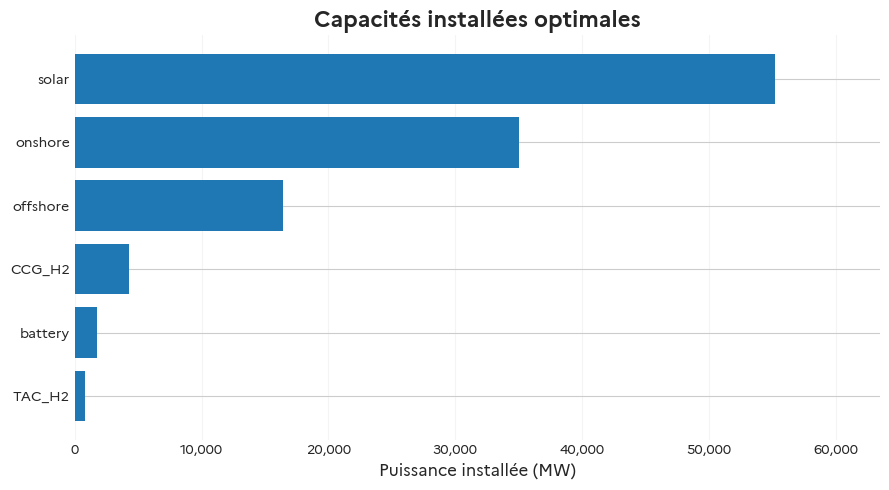

In [181]:
import json
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mtick
import os

data = parc["capacites_MW"].copy()

# ------------------------
# AJOUT H2 CCG + TAC
# ------------------------
if "H2" in parc:

    Pmax_CCG_unite = 430  # MW par unité CCG
    Pmax_TAC_unite = 85   # MW par unité TAC

    nb_CCG = parc["H2"]["CCG"]["nombre_installees"]
    nb_TAC = parc["H2"]["TAC"]["nombre_installees"]

    data["CCG_H2"] = nb_CCG * Pmax_CCG_unite
    data["TAC_H2"] = nb_TAC * Pmax_TAC_unite

# ------------------------
# Icônes associées
# ------------------------
icons = {
    "onshore": "assets/icons/eolien.png",
    "offshore": "assets/icons/eolien_offshore.png",
    "solar": "assets/icons/solaire.png",
    "battery": "assets/icons/batterie.png",
    "CCG_H2": "assets/icons/h2.png",
    "TAC_H2": "assets/icons/h2.png",
}

# ------------------------
# Fonction icône
# ------------------------
def add_icon(ax, x, y, icon_path, zoom=0.08):
    if not os.path.exists(icon_path):
        return
    img = plt.imread(icon_path)
    ab = AnnotationBbox(
        OffsetImage(img, zoom=zoom),
        (x, y),
        frameon=False,
        box_alignment=(0, 0.5)
    )
    ax.add_artist(ab)

# ------------------------
# Préparation données
# ------------------------
labels = list(data.keys())
values = list(data.values())



labels, values = zip(*sorted(zip(labels, values), key=lambda t: t[1]))

# ------------------------
# Plot
# ------------------------
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(labels, values)

ax.set_title("Capacités installées optimales", fontweight="bold")
ax.set_xlabel("Puissance installée (MW)")
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

# Icônes
xmin, xmax = ax.get_xlim()
icon_x = xmin + (xmax - xmin) * 0.02

for y, label in enumerate(labels):
    add_icon(ax, icon_x, y, icons.get(label, ""), zoom=0.07)

ax.margins(x=0.15)
ax.grid(axis="x", alpha=0.2)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

## **3. Capacités de stockage**

/tmp/ipykernel_6798/1944533083.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Prod_totale"] = df["H2_CCG"] + df["H2_TAC"] + df["Hydro"] + df["Solar"] + df["Onshore"] + df["Offshore"]
/tmp/ipykernel_6798/1944533083.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Ecret"] = df["Prod_totale"] - df["Load"]
/tmp/ipykernel_6798/1944533083.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

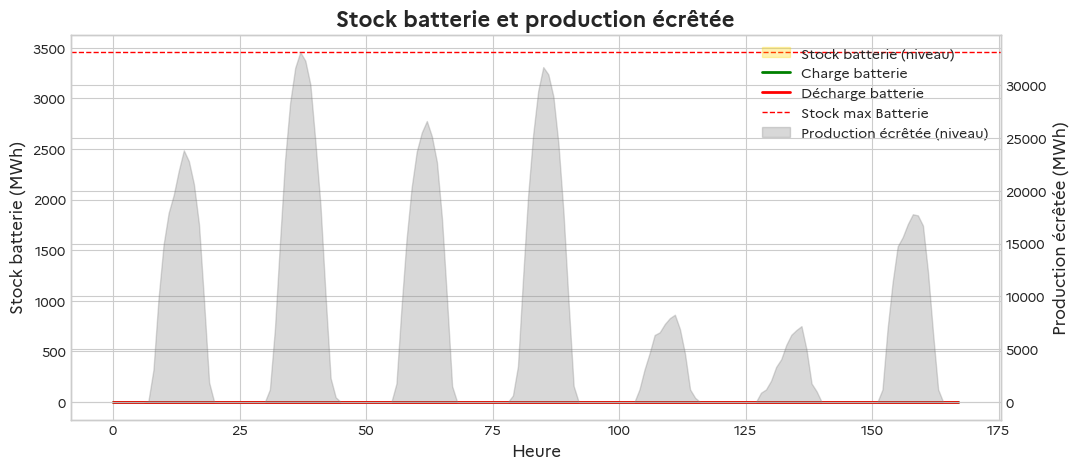

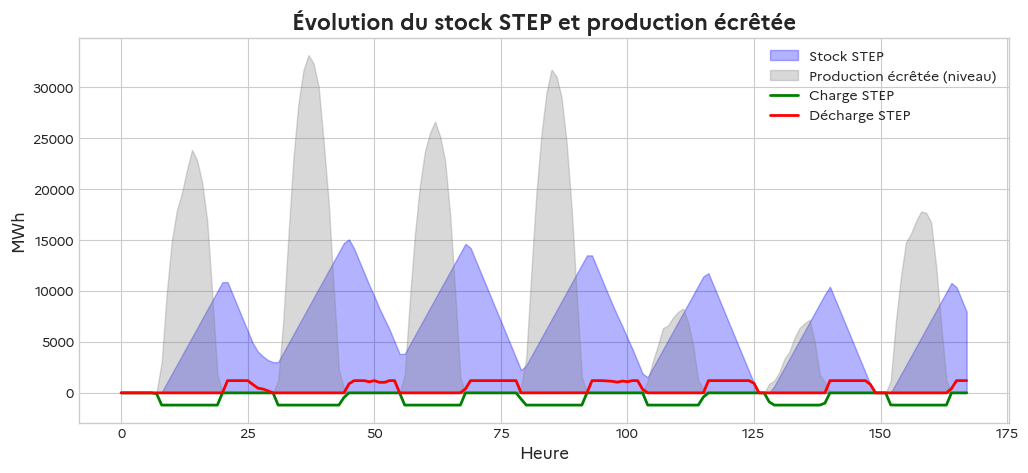

In [182]:
import numpy as np

CapaBattery = parc["capacites_MW"]["battery"]
d_battery = 2   # heures
stock_max_battery = CapaBattery * d_battery
rbattery = 0.85

# --- Calcul de la production totale ---
df["Prod_totale"] = df["H2_CCG"] + df["H2_TAC"] + df["Hydro"] + df["Solar"] + df["Onshore"] + df["Offshore"]

# --- Production écrêtée avant utilisation des stocks ---
df["Ecret"] = df["Prod_totale"] - df["Load"]
df["Ecret"] = df["Ecret"].clip(lower=0)  # pas de valeurs négatives

# --- Axe temps ---
time = df.index

# --- Plot Stock Batterie ---

fig, ax1 = plt.subplots(figsize=(12,5))

# Axe principal : stock batterie
ax1.fill_between(time, 0, df["Battery_stock"], color='gold', alpha=0.3, label="Stock batterie (niveau)")

ax1.plot(time, -df["Battery_charge"]*rbattery, linewidth=2, color='green', label="Charge batterie")
ax1.plot(time, df["Battery_discharge"]/rbattery, linewidth=2, color='red', label="Décharge batterie")
ax1.axhline(y=stock_max_battery, linestyle="--", linewidth=1, color="red", label="Stock max Batterie")
ax1.set_xlabel("Heure")
ax1.set_ylabel("Stock batterie (MWh)")


# Axe secondaire : production écrêtée
ax2 = ax1.twinx()
# ax2.plot(time, df["Ecret"], linestyle="--", linewidth=2,color="gray", label="Production écrêtée")
ax2.fill_between(time, 0, df["Ecret"], color='gray', alpha=0.3, label="Production écrêtée (niveau)")
ax2.set_ylabel("Production écrêtée (MWh)")

# Légende combinée
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.title("Stock batterie et production écrêtée")
plt.show()

# --- Plot Stock STEP ---
# On peut calculer stock max STEP si on a Pmax_STEP et durée max 24*7h
#stock_max_STEP = ?

plt.figure(figsize=(12,5))
#plt.plot(time, df["STEP_stock"], linewidth=2, color='blue', label="Stock STEP")
plt.fill_between(time, 0, df["STEP_stock"], color='blue', alpha=0.3, label="Stock STEP")
#plt.axhline(y=stock_max_STEP, linestyle="--", color="red", label="Stock max STEP")
plt.fill_between(time, 0, df["Ecret"], color='gray', alpha=0.3, label="Production écrêtée (niveau)")
plt.plot(time, -df["STEP_charge"], linewidth=2, color='green', label = "Charge STEP")
plt.plot(time, df["STEP_discharge"], linewidth=2, color='red', label = "Décharge STEP")
plt.title("Évolution du stock STEP et production écrêtée")
plt.xlabel("Heure")
plt.ylabel("MWh")
plt.legend()
plt.show()



## **4. Hydraulique**

## **5. Centrales H2**

## **6. Défaillance**

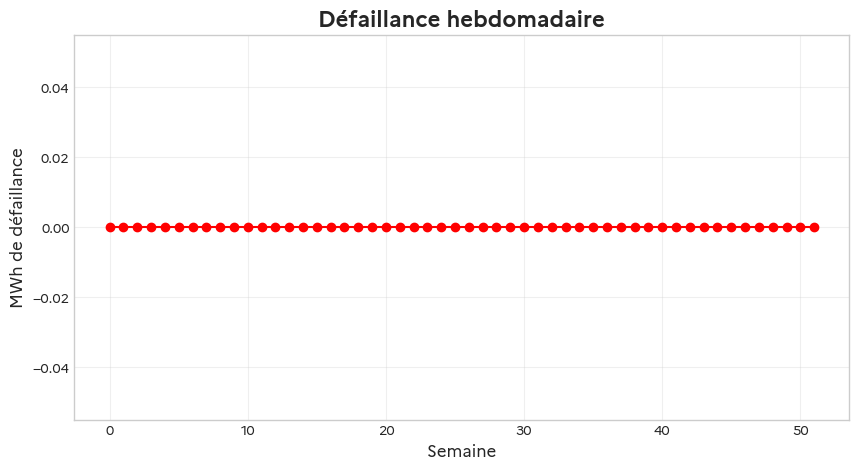

In [ ]:
defaillance = df_global["Defailance"]
weeks = np.arange(len(defaillance)) // (7*24)
weekly_defaillance = [defaillance[weeks == w].sum() for w in np.unique(weeks)]

plt.figure(figsize=(10,5))
plt.plot(weekly_defaillance, marker='o', color='red')
plt.title("Défaillance hebdomadaire")
plt.xlabel("Semaine")
plt.ylabel("MWh de défaillance")
plt.grid(alpha=0.3)
plt.show()

## **6. Evolution des capacités dans l'optimisation**

In [189]:
weeks = evolution_parc["semaine"]
onshore = evolution_parc["capacites_MW"]["onshore"]
offshore = evolution_parc["capacites_MW"]["offshore"]
solar = evolution_parc["capacites_MW"]["solar"]
battery = evolution_parc["capacites_MW"]["battery"]


ccg = [val * 430.0 for val in evolution_parc["H2"]["CCG"].get("nombre_installees", [0])]
tac = [val * 85.0 for val in evolution_parc["H2"]["TAC"].get("nombre_installees", [0])] 

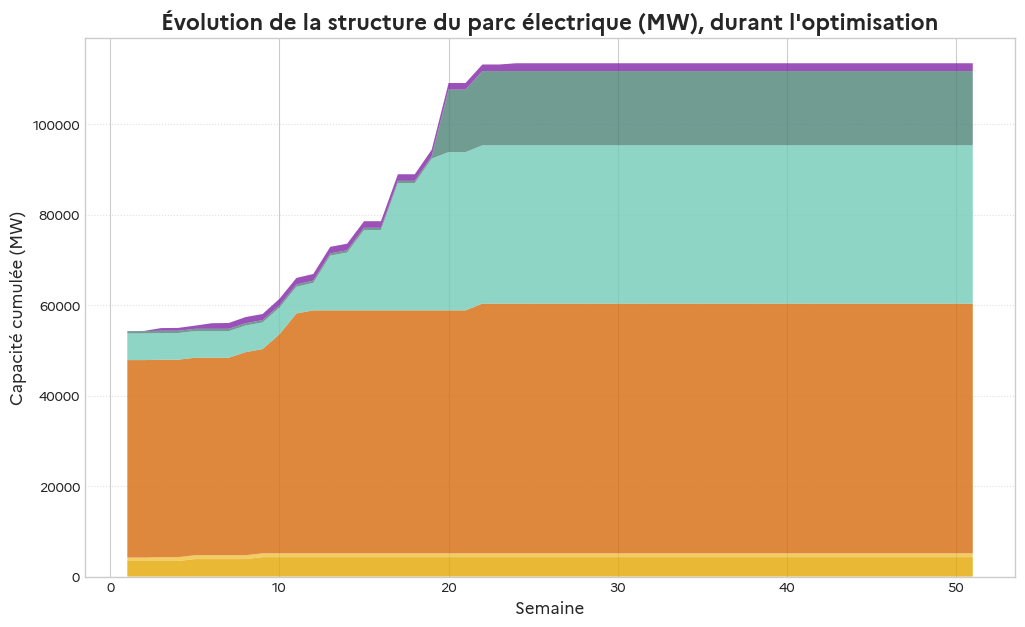

In [190]:
plt.figure(figsize=(12, 7))

# On empile les données
plt.stackplot(weeks, ccg, tac, solar,onshore, offshore, battery, 
              labels=["CCG H2", "TAC H2", "Solaire", "Onshore", "Offshore", "Batterie"],
              colors=[palette["H2_CCG"], palette["H2_TAC"], palette["Solar"], palette["Onshore"], palette["Offshore"], palette["Battery"]],
              alpha=0.8)

plt.title("Évolution de la structure du parc électrique (MW), durant l'optimisation")
plt.ylabel("Capacité cumulée (MW)")
plt.xlabel("Semaine")
plt.grid(axis='y', linestyle=':', alpha=0.6)

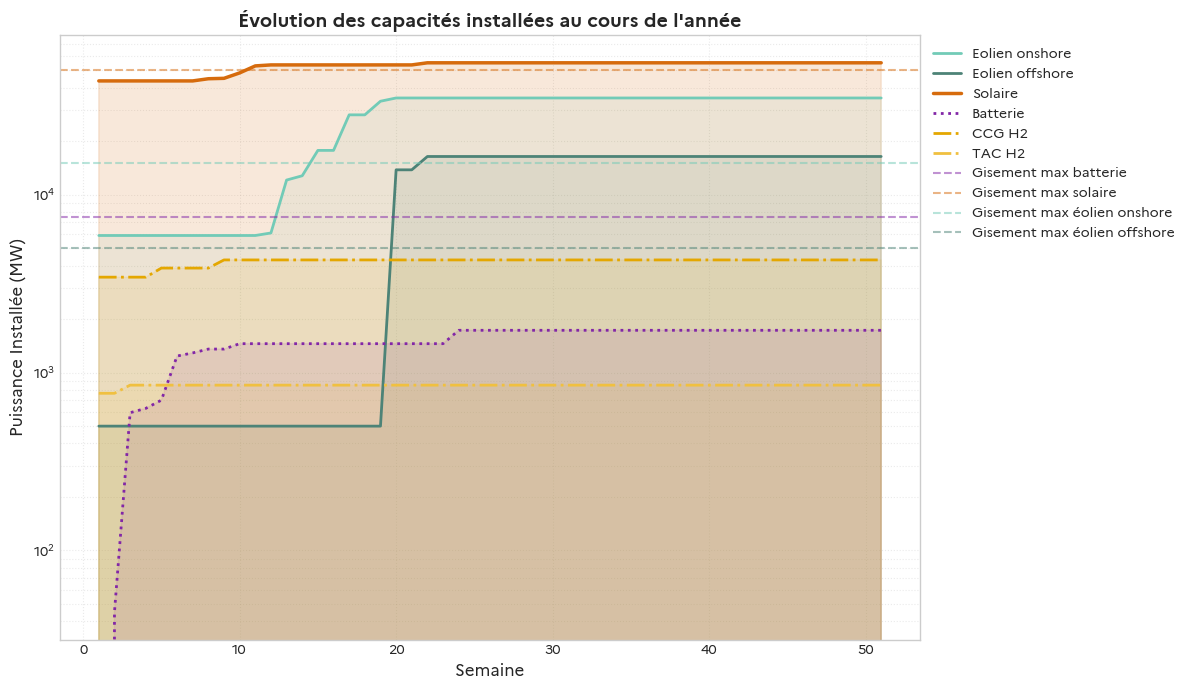

In [191]:
import matplotlib.pyplot as plt

# --- 1. Préparation des données (Identique à votre code) ---
weeks = evolution_parc["semaine"]
onshore = evolution_parc["capacites_MW"]["onshore"]
offshore = evolution_parc["capacites_MW"]["offshore"]
solar = evolution_parc["capacites_MW"]["solar"]
battery = evolution_parc["capacites_MW"]["battery"]

# Vos listes calculées précédemment
ccg = [val * 430.0 for val in evolution_parc["H2"]["CCG"].get("nombre_installees", [0])]
tac = [val * 85.0 for val in evolution_parc["H2"]["TAC"].get("nombre_installees", [0])]

# Palette de couleurs (si vous n'en avez pas, j'en crée une par défaut)
# palette = {...}

# --- 2. Création de la figure ---
plt.figure(figsize=(12, 7))

# --- 3. Tracé des Courbes + Ajout du STYLE "Fill Between" ---

# Éolien Onshore
plt.plot(weeks, onshore, label="Eolien onshore", color=palette["Onshore"], linewidth=2)
plt.fill_between(weeks, onshore, color=palette["Onshore"], alpha=0.1) # Remplissage léger

# Éolien Offshore
plt.plot(weeks, offshore, label="Eolien offshore", color=palette["Offshore"], linewidth=2)
plt.fill_between(weeks, offshore, color=palette["Offshore"], alpha=0.1)

# Solaire
plt.plot(weeks, solar, label="Solaire", color=palette["Solar"], linewidth=2.5)
plt.fill_between(weeks, solar, color=palette["Solar"], alpha=0.15) # Un peu plus opaque pour le Solaire

# Batterie
plt.plot(weeks, battery, label="Batterie", color=palette["Battery"], linewidth=2, linestyle=':')
plt.fill_between(weeks, battery, color=palette["Battery"], alpha=0.1)

# CCG H2
plt.plot(weeks, ccg, label="CCG H2", color=palette["H2_CCG"], linewidth=2, linestyle='-.')
plt.fill_between(weeks, ccg, color=palette["H2_CCG"], alpha=0.1)

# TAC H2
plt.plot(weeks, tac, label="TAC H2", color=palette["H2_TAC"], linewidth=2, linestyle='-.')
plt.fill_between(weeks, tac, color=palette["H2_TAC"], alpha=0.1)


# --- 4. Cosmétique et Gisements (Identique à votre code) ---
plt.title("Évolution des capacités installées au cours de l'année", fontsize=14, fontweight='bold')

plt.axhline(y=7500, color=palette["Battery"], linestyle='--', alpha=0.5, label="Gisement max batterie")
plt.axhline(y=50000, color=palette["Solar"], linestyle='--', alpha=0.5, label="Gisement max solaire")
plt.axhline(y=15000, color=palette["Onshore"], linestyle='--', alpha=0.5, label="Gisement max éolien onshore")
plt.axhline(y=5000, color=palette["Offshore"], linestyle='--', alpha=0.5, label="Gisement max éolien offshore")

plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Sortir la légende pour ne pas cacher les gisements

plt.yscale("log")
plt.xlabel("Semaine", fontsize=12)
plt.ylabel("Puissance Installée (MW)", fontsize=12)
plt.grid(True, which="both", linestyle=':', alpha=0.4) # Grille adaptée au log

plt.tight_layout() # Évite que la légende ne soit coupée
plt.show()